In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parent directory that contains the CHARMtools package folder
CHARMTOOLS_PARENT = Path('/mnt/ssd/zliu/run_charm')
sys.path.insert(0, str(CHARMTOOLS_PARENT))

from CHARMtools.obj.Cell3D import Cell3D

%config InlineBackend.figure_format = 'retina'


In [2]:
# Load example 3D genome structure (20 kb bins)
DATA_DIR = Path('/mnt/ssd/zliu/run_charm/CHARMtools/example_with_data/data')
tdg_path = DATA_DIR / 'P9016.20k.3dg.gz'
cell = Cell3D(tdg_path=str(tdg_path), cellname='P9016_20k_demo', resolution=20_000)

print(f'Loaded file: {tdg_path}')
cell.get_info()


Loaded file: /mnt/ssd/zliu/run_charm/CHARMtools/example_with_data/data/P9016.20k.3dg.gz
CHARMtools Cell3D object v0.2
Cell name: P9016_20k_demo
Resolution: 20000
Features: []
Chromatin3DStructure with 247520 records
Object is stored on disk: False
Metadata:


''

In [3]:
# Basic inspection
summary = cell.summary()
display(pd.Series({
    'cellname': summary['cellname'],
    'resolution': summary['resolution'],
    'n_points': summary['n_points'],
    'n_chromosomes': len(summary['chromosomes']),
}))

cell.get_data().head()


cellname         P9016_20k_demo
resolution                20000
n_points                 247520
n_chromosomes                40
dtype: object

,chrom,pos,x,y,z,chrom_code
0,chr1b,3160000,-28.787357,-5.200088,13.954934,21
1,chr1b,3180000,-28.664465,-5.763839,14.061148,21
2,chr1b,3200000,-29.695332,-5.460523,13.512159,21
3,chr1b,3220000,-28.635164,-6.010075,13.408425,21
4,chr1b,3240000,-28.629362,-6.684829,13.632798,21


## 1) Whole-cell 3D view

`feature=None` colors by chromosome, which gives a direct chromosome-territory style view.


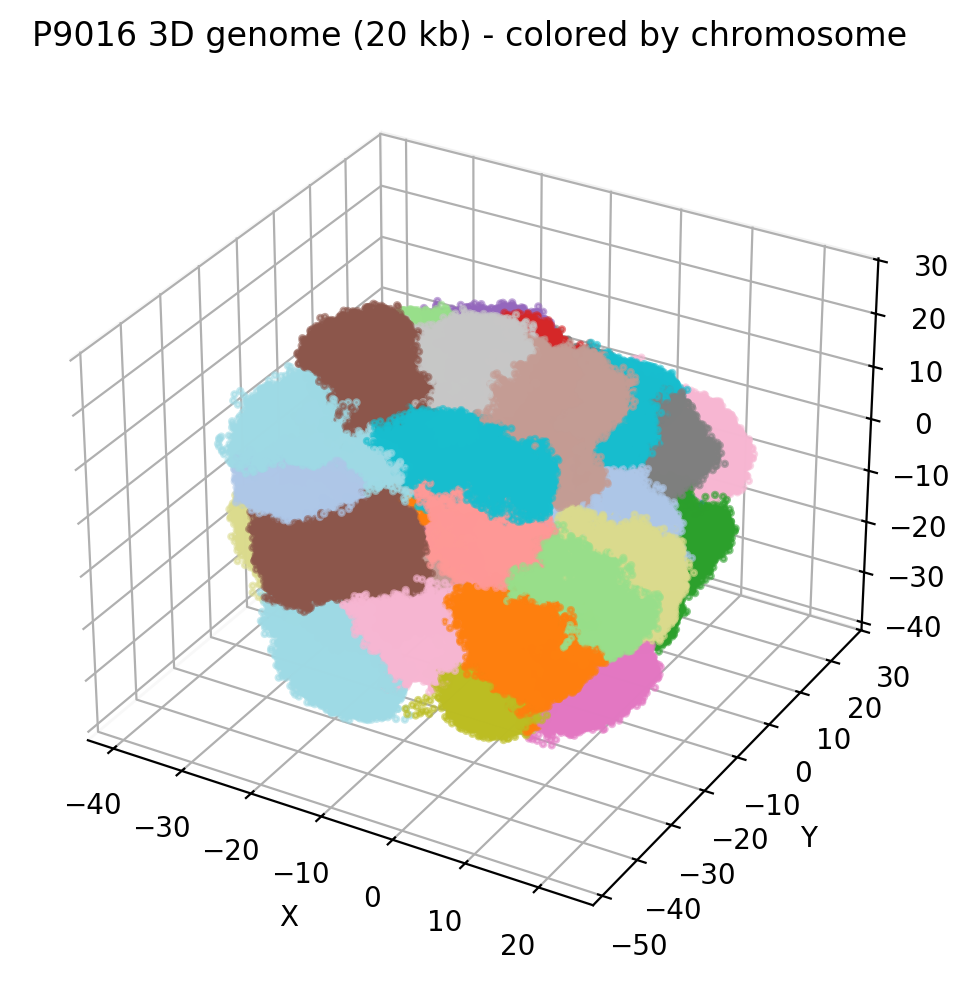

In [4]:
fig, ax = cell.plot3D(
    feature=None,
    point_size=4,
    alpha=0.55,
    figsize=(5, 5),
    title='P9016 3D genome (20 kb) - colored by chromosome',
    color_map="tab20"
)
plt.show()


## 2) Chromosome territory metrics

Use `calc_chromosome_territories_metrics()` to summarize each chromosome territory center, radius of gyration, and volume.


In [5]:
territory_metrics = cell.calc_chromosome_territories_metrics()
territory_df = pd.DataFrame.from_dict(territory_metrics, orient='index').reset_index()
territory_df = territory_df.rename(columns={'index': 'chrom'})

centers = np.vstack(territory_df['center'].to_numpy())
territory_df[['center_x', 'center_y', 'center_z']] = centers
territory_df = territory_df.drop(columns=['center'])

territory_df = territory_df.sort_values('radius_of_gyration', ascending=False).reset_index(drop=True)
territory_df.head(10)


,chrom,radius_of_gyration,volume,n_points,center_x,center_y,center_z
0,chr13b,8.898603,4275.798013,5598,-24.503536,-12.553440,-5.390294
1,chrXb,8.756825,5518.175131,6432,-28.065662,-21.894699,6.315352
2,chr8a,8.575761,4963.142142,6203,14.148006,-15.190966,-10.143867
3,chr12b,8.512920,5388.299074,5478,-13.713456,-8.146489,-5.746002
4,chr5b,8.049375,4874.802900,7180,7.289935,3.827157,2.343512
5,chr2b,7.894014,5836.424532,8760,-16.674479,-23.969395,-20.167233
6,chr2a,7.848279,5101.993396,8708,0.825523,-8.526093,12.383372
7,chr1b,7.701278,5218.632711,9494,-22.400917,-13.908486,13.760449
8,chr6b,7.562158,5602.739781,7264,1.491076,7.270850,-16.789135
9,chr4b,7.536865,5877.856928,7333,6.984852,14.487641,-2.361788


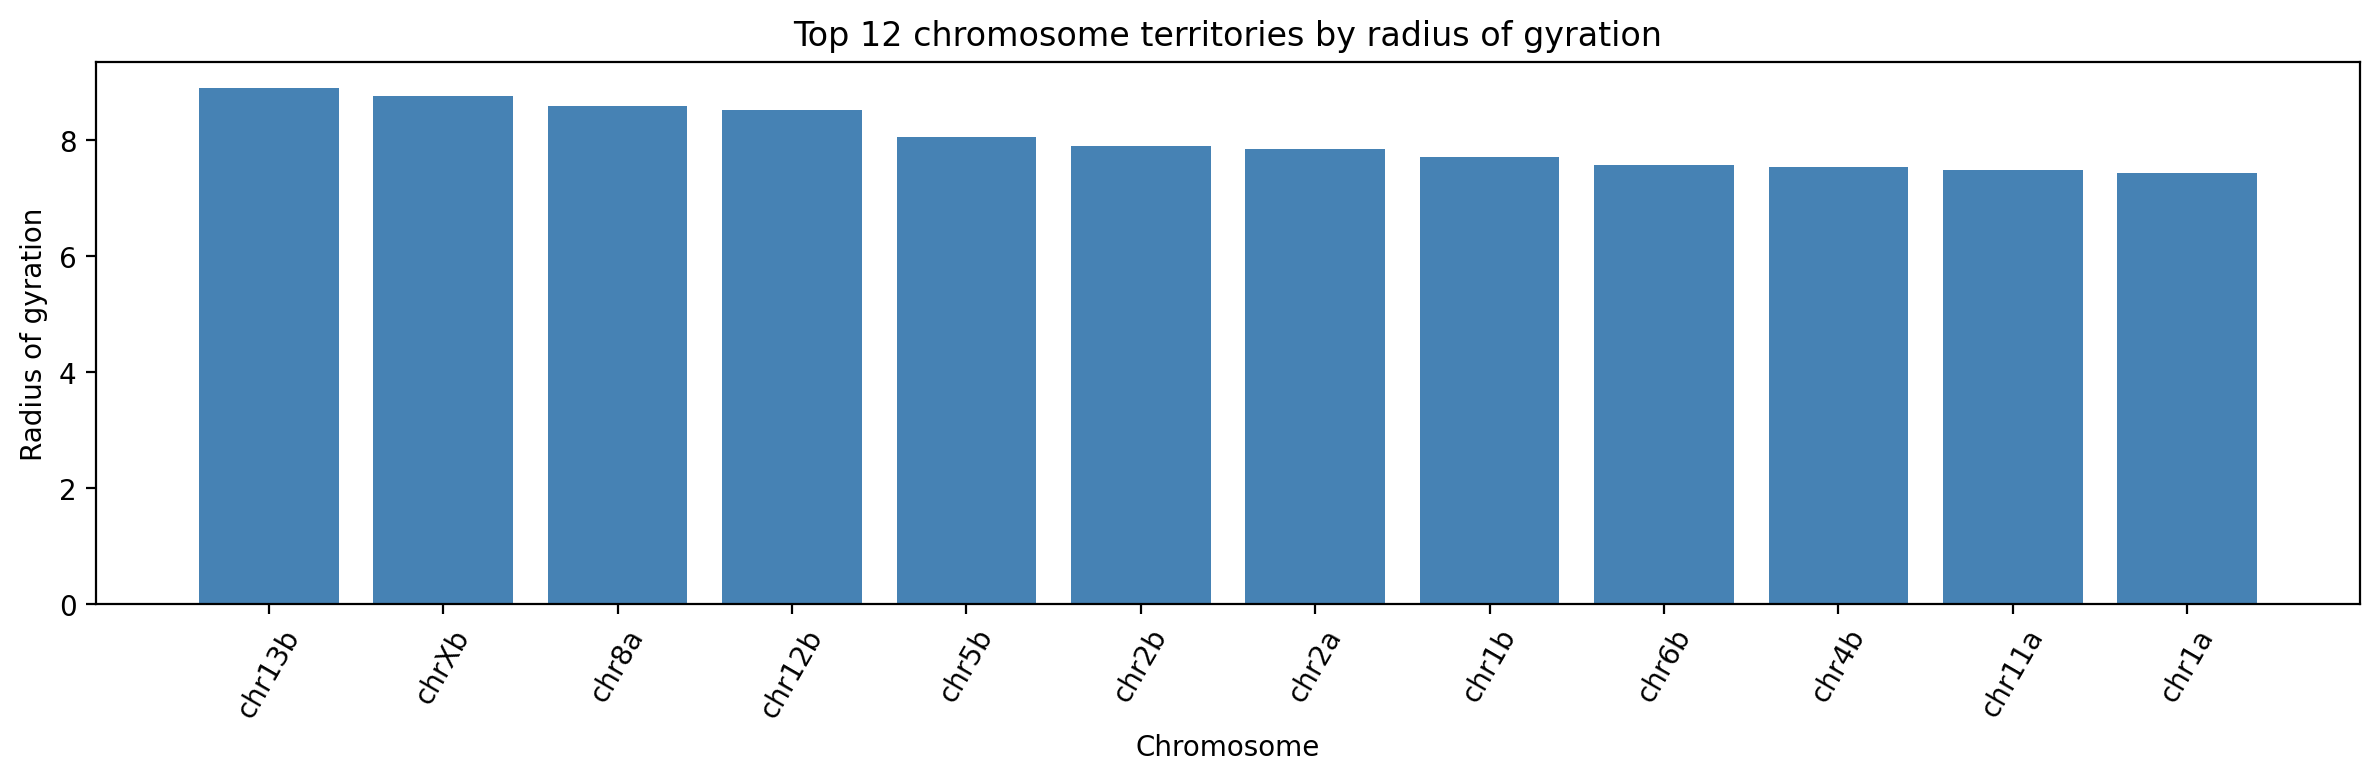

In [6]:
# Compare top chromosome territories by radius of gyration
top_n = 12
plot_df = territory_df.head(top_n)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(plot_df['chrom'], plot_df['radius_of_gyration'], color='steelblue')
ax.set_title(f'Top {top_n} chromosome territories by radius of gyration')
ax.set_xlabel('Chromosome')
ax.set_ylabel('Radius of gyration')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3239239/3692841110.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chrom, g in plot_points.groupby('chrom'):


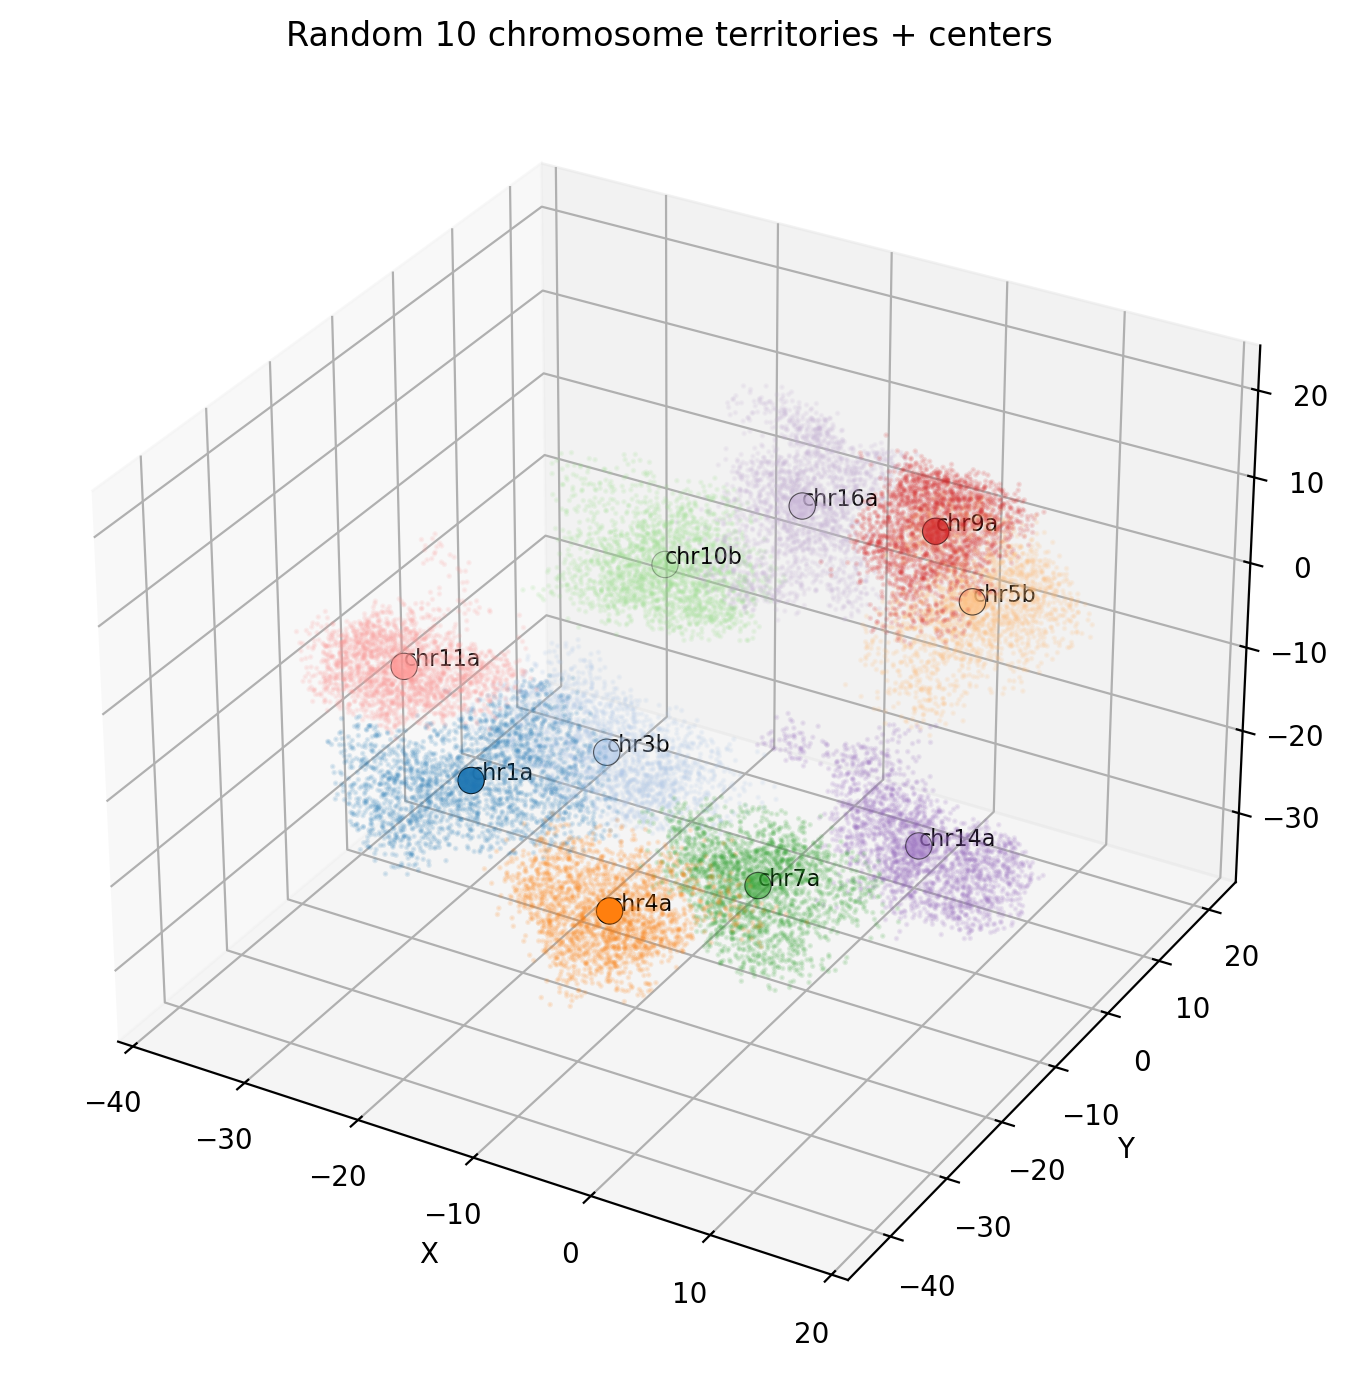

In [7]:
# Territory-center map: random 10 chromosomes + matching semi-transparent colors
center_df = territory_df.sample(n=min(10, len(territory_df)), random_state=0).copy()
center_df = center_df.sort_values('n_points', ascending=False).reset_index(drop=True)

plot_points = cell.get_data()[['chrom', 'x', 'y', 'z']].copy()
plot_points = plot_points[plot_points['chrom'].isin(center_df['chrom'])].copy()

sampled_points = []
for chrom, g in plot_points.groupby('chrom'):
    sampled_points.append(g.sample(n=min(2000, len(g)), random_state=0))
plot_points = pd.concat(sampled_points, ignore_index=True)

cmap = plt.get_cmap('tab20')
chrom_to_color = {chrom: cmap(i % 20) for i, chrom in enumerate(center_df['chrom'])}

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for chrom in center_df['chrom']:
    pts = plot_points[plot_points['chrom'] == chrom]
    ax.scatter(
        pts['x'], pts['y'], pts['z'],
        s=1, alpha=0.12, color=chrom_to_color[chrom]
    )

center_colors = [chrom_to_color[c] for c in center_df['chrom']]
ax.scatter(
    center_df['center_x'], center_df['center_y'], center_df['center_z'],
    c=center_colors, s=90, edgecolor='black', linewidth=0.4
)

for row in center_df.itertuples(index=False):
    ax.text(row.center_x, row.center_y, row.center_z, row.chrom, fontsize=8)

ax.set_title('Random 10 chromosome territories + centers')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.show()


## 3） Zoom into one chromosome territory


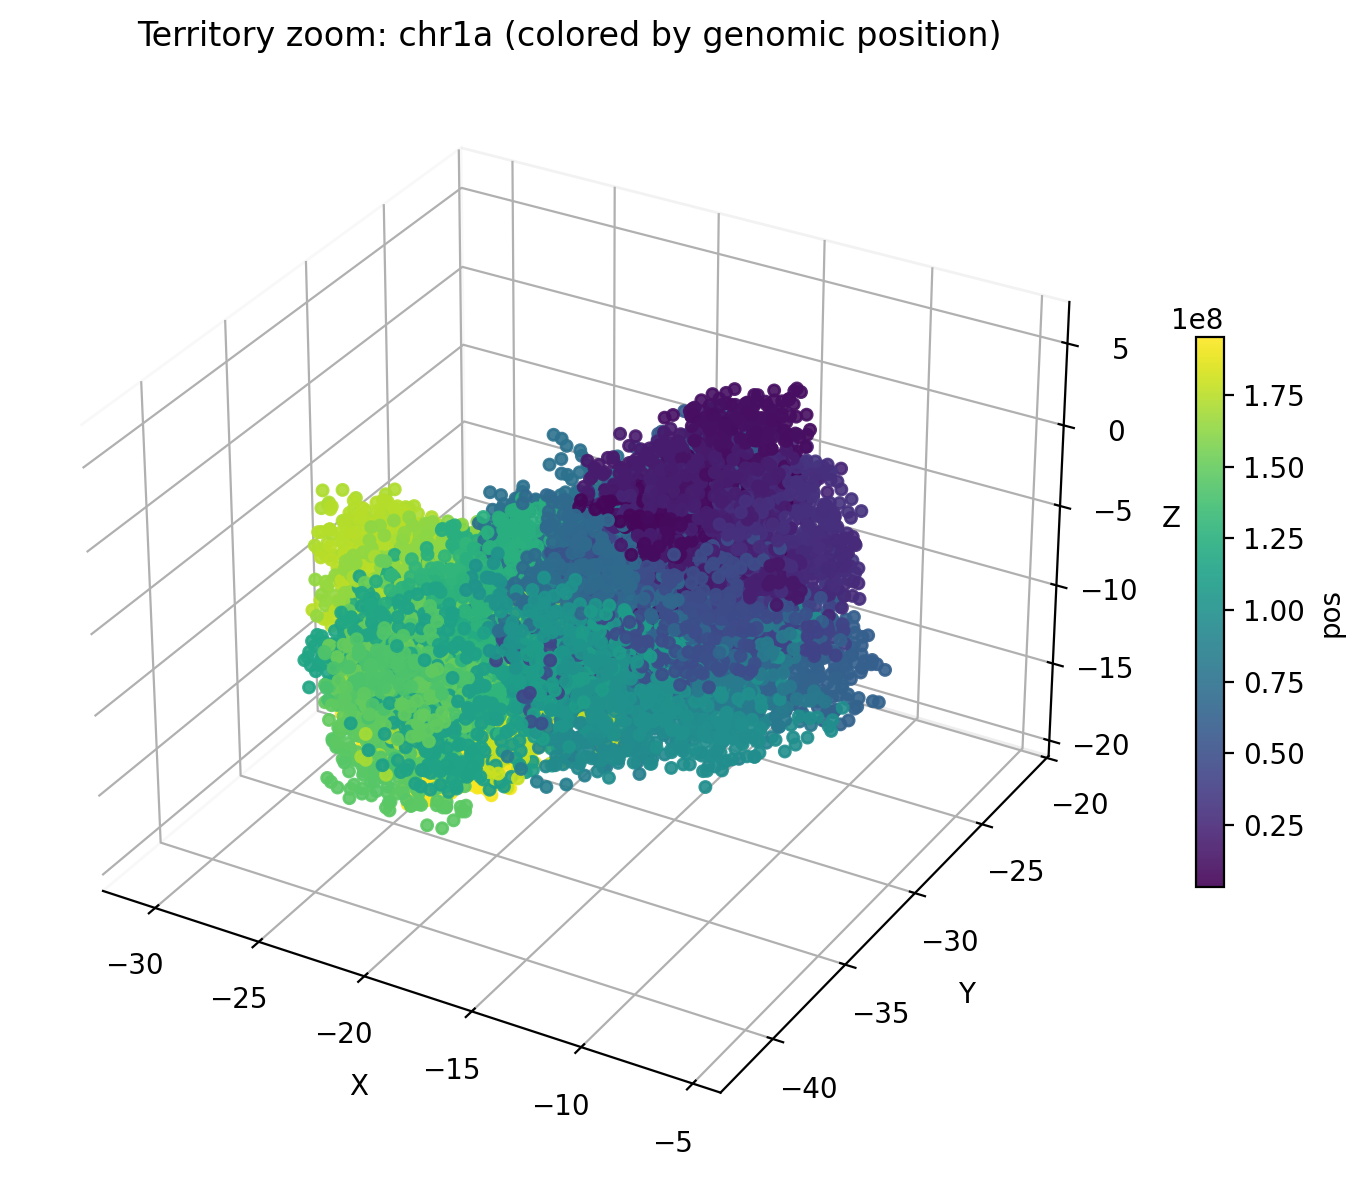

In [8]:
target_chrom = 'chr1a'
fig, ax = cell.plot3D(
    genome_coord=target_chrom,
    feature='pos',
    color_map='viridis',
    point_size=16,
    alpha=0.9,
    figsize=(8, 6),
    title=f'Territory zoom: {target_chrom} (colored by genomic position)',
)
plt.show()


## 5) One-row view: chromosome territory + CpG/ATAC/CT in 2 pr


In [10]:
cell.add_bedGraph_data(str(DATA_DIR / 'M23.CpG.20000.txt'), column_name='CpG', resolution=20_000, type='all')
cell.add_bed_data(str(DATA_DIR / 'P9016.atac.frag.bed.gz'), column_name='ATAC', type='allelic_resolved')
cell.add_bed_data(str(DATA_DIR / 'P9016.ct.frag.bed.gz'), column_name='CT', type='allelic_resolved')

for feat in ['CpG', 'ATAC', 'CT']:
    col = f'{feat}_sum_in_radius_2'
    cell.add_feature_in_radius(
        feature=feat,
        radius=2,
        aggregation='mean',
        include_self=True,
        new_column_name=col
    )


/mnt/ssd/zliu/run_charm/CHARMtools/obj/cell3d_features.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(merge_intervals)
/mnt/ssd/zliu/run_charm/CHARMtools/obj/cell3d_features.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(merge_intervals)


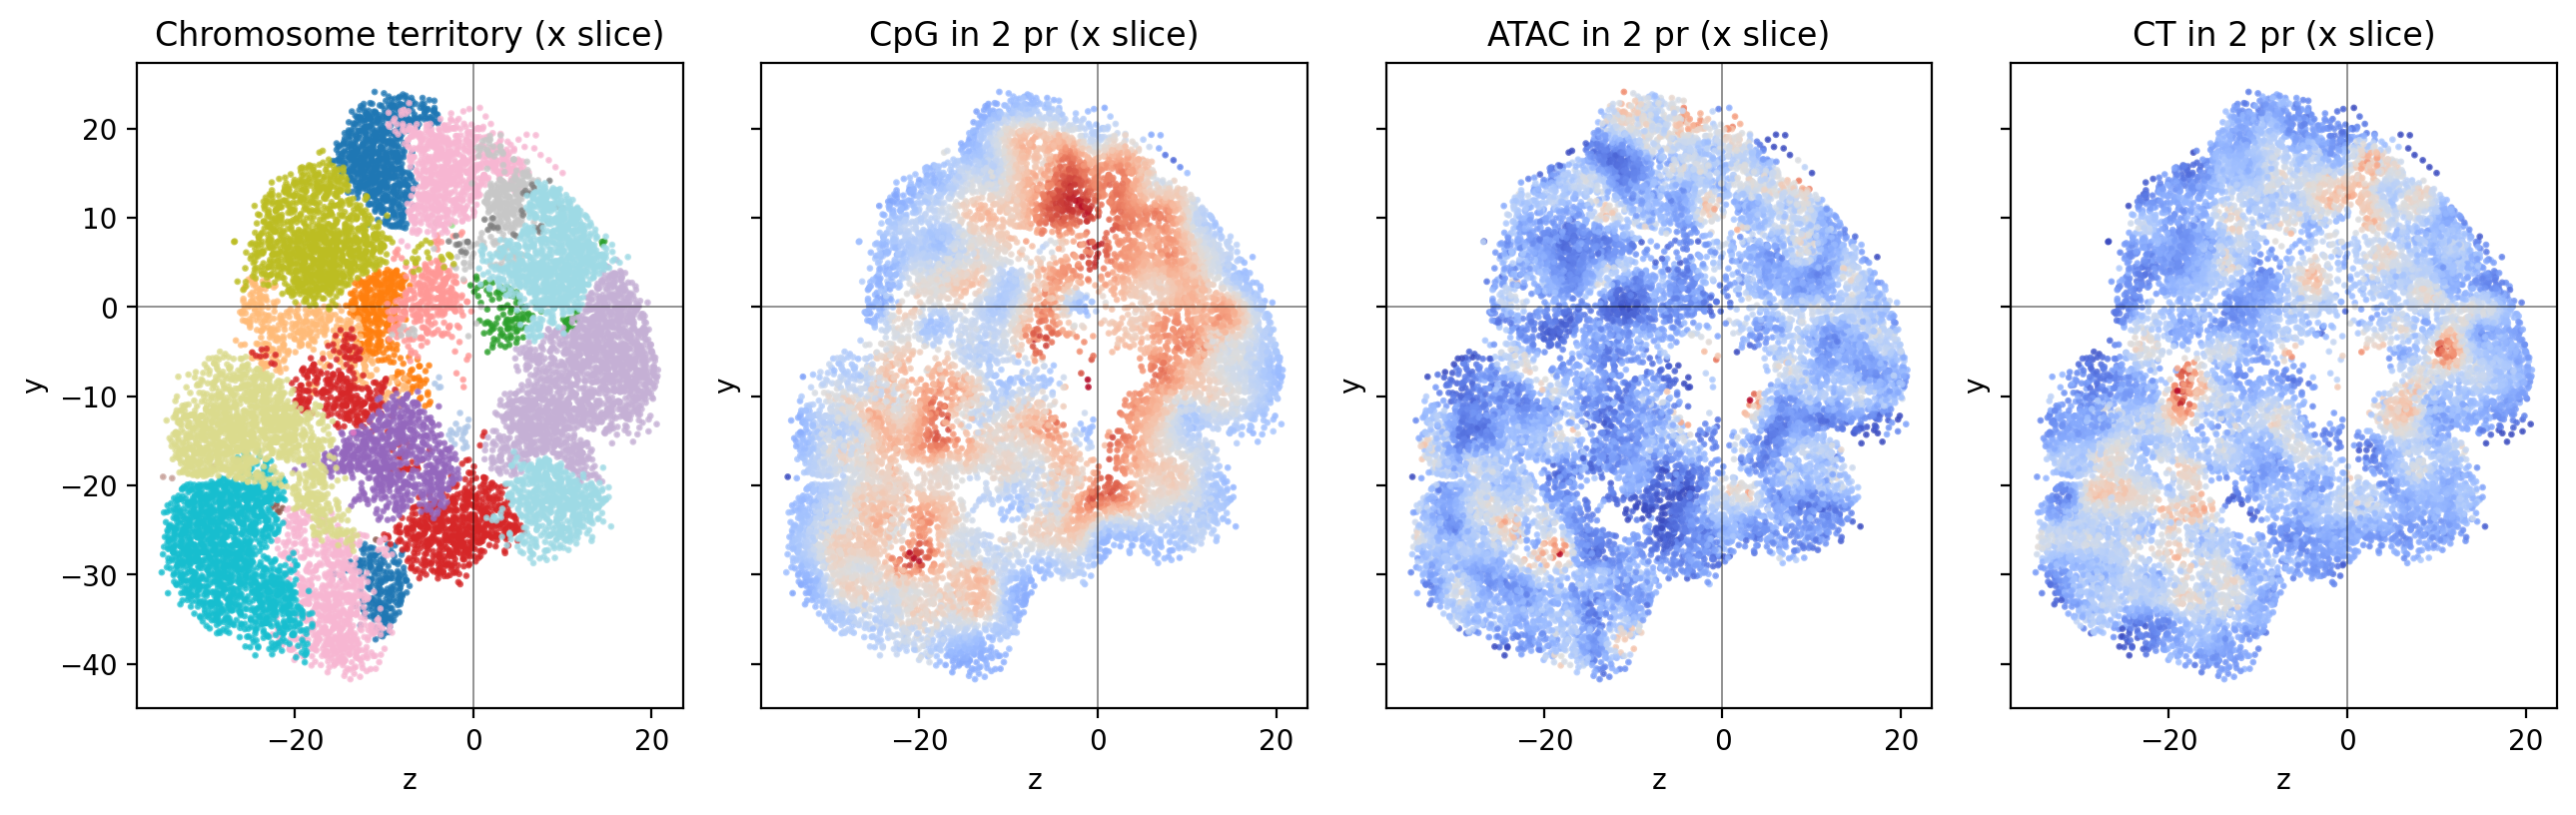

In [15]:
# Slice: keep only points with -1 < x < 1, then plot on x-y plane
plot_df = cell.get_data().query('x > -1 and x < 1').copy()

fig, axes = plt.subplots(1, 4, figsize=(13,4), sharex=True, sharey=True)

# 1) Chromosome territory (still use coolwarm as requested)
chrom_code = pd.Categorical(plot_df['chrom']).codes
sc0 = axes[0].scatter(plot_df['z'], plot_df['y'], c=chrom_code, cmap='tab20', s=2, alpha=0.7)
axes[0].set_title('Chromosome territory (x slice)')

# 2) CpG in 2 pr
sc1 = axes[1].scatter(plot_df['z'], plot_df['y'], c=plot_df['CpG_sum_in_radius_2'], cmap='coolwarm', s=2, alpha=0.75)
axes[1].set_title('CpG in 2 pr (x slice)')

# 3) ATAC in 2 pr
sc2 = axes[2].scatter(plot_df['z'], plot_df['y'], c=plot_df['ATAC_sum_in_radius_2'], cmap='coolwarm', s=2, alpha=0.75)
axes[2].set_title('ATAC in 2 pr (x slice)')

# 4) CT in 2 pr
sc3 = axes[3].scatter(plot_df['z'], plot_df['y'], c=plot_df['CT_sum_in_radius_2'], cmap='coolwarm', s=2, alpha=0.75)
axes[3].set_title('CT in 2 pr (x slice)')

for ax in axes:
    ax.axhline(0, color='black', lw=0.6, alpha=0.5)
    ax.axvline(0, color='black', lw=0.6, alpha=0.5)
    ax.set_xlabel('z')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()
